<a href="https://colab.research.google.com/github/FelipeConza/IntroduccionSistemasInformacion/blob/Proyecto1BISI/ExamenPractico_FelipeConza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
RealStateEcuador = pd.read_csv('/content/real_estate_ecuador_200k.csv', on_bad_lines='skip')
RealStateEcuador.head()

/tmp/ipykernel_647/430545061.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  RealStateEcuador = pd.read_csv('/content/real_estate_ecuador_200k.csv', on_bad_lines='skip')


,Titulo,Precio,Provincia,Lugar,Num. dormitorios,Num. banos,Area,Num. garages
0,Rento Suite 75 metros sector Republica del Sal...,395.66,Pichincha,"Pichincha, Av. Portugal & Av República de El S...",1.0,2.0,65.0,1.0
1,“Rento departamento en sector la Carolina”,773.69,Pichincha,"Pichincha, Catalina de Aldaz & Av. Portugal, Q...",2.0,2.0,88.0,1.0
2,Se Renta Amplio Departamento en el Sector de l...,616.94,Pichincha,"Pichincha, Marcos Jofre, Quito, Ecuador",4.0,4.0,214.0,1.0
3,Hermoso departamento de arriendo de oportunida...,286.69,Pichincha,"Pichincha, De la Prensa Y del Maestro, Quito, ...",2.0,2.0,98.0,1.0
4,"EN RENTA DEPARTAMENTO, CONJUNTO DIVINO NIÑO",131.54,Pichincha,"Pichincha, Turubamaba, Ecuador",3.0,2.0,53.0,NaN


# ***Perspectiva Financiera***

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Clean 'Provincia' column first to ensure consistency for grouping later
RealStateEcuador['Provincia'] = RealStateEcuador['Provincia'].str.strip().str.title()

# Map cities found in 'Provincia' column to their respective provinces
province_mapping = {
    'Quito': 'Pichincha',
    'Guayaquil': 'Guayas'
}
RealStateEcuador['Provincia'] = RealStateEcuador['Provincia'].replace(province_mapping)

# Handle invalid province names like '1.0'
RealStateEcuador['Provincia'] = RealStateEcuador['Provincia'].replace('1.0', 'Desconocido')

#Perspectiva financiera:

#i. Precio Promedio de Alquiler General
RealStateEcuador['Precio'] = pd.to_numeric(RealStateEcuador['Precio'], errors='coerce')
precio_promedio = RealStateEcuador['Precio'].mean()
print(f'El precio promedio de las propiedades en GENERAL es: {precio_promedio:.2f}')

print("---------------------------------------------------------------------------------")

# Función mejorada para extraer la ciudad de la columna 'Lugar'
def extract_city_improved(location_string):
    if pd.isna(location_string):
        return 'Desconocido'

    # Normalize the input string for easier comparison
    location_string_lower = location_string.lower()

    # List of common Ecuadorian cities (can be expanded)
    ecuadorian_cities = [
        'quito', 'guayaquil', 'cuenca', 'manta', 'portoviejo', 'machala', 'ambato',
        'riobamba', 'loja', 'santo domingo', 'esmeraldas', 'latacunga', 'milagro',
        'quevedo', 'ibarra', 'daule', 'durán', 'babahoyo', 'samborondón', 'sangolquí',
        'machachi', 'salinas', 'tonsupa', 'balao', 'santa elena', 'general villamil',
        'san rafael', 'otavalo', 'cotacachi', 'gualaceo', 'azuay', 'montañita', 'la troncal'
    ]

    # 1. First, check for exact city matches in the full string (using word boundaries)
    for city in ecuadorian_cities:
        if re.search(r'\b' + re.escape(city) + r'\b', location_string_lower):
            return city.title() # Return in Title Case for consistency

    # 2. Fallback logic if no known city is found by the first pass
    parts = [p.strip() for p in location_string.split(',') if p.strip()] # Remove empty parts

    if not parts:
        return 'Desconocido'

    # Provinces and countries to exclude (lower case for comparison)
    provinces_or_countries_to_exclude = [
        'pichincha', 'guayas', 'manabí', 'azuay', 'el oro', 'esmeraldas', 'los rios',
        'loja', 'imbabura', 'cotopaxi', 'chimborazo', 'santo domingo de los tsáchilas',
        'tungurahua', 'cañar', 'orellana', 'sucumbíos', 'carchi', 'bolívar',
        'pastaza', 'morona santiago', 'zamora chinchipe', 'santa elena', 'napo', 'galápagos',
        'ecuador'
    ]

    # Expanded list of street/address related keywords to exclude (lower case)
    street_keywords_to_exclude = [
        'avenida', 'av.', 'calle', 'pasaje', 'sector', 'km', 'via', 'vía', 'carrera', 'transversal',
        'boulevard', 'circunvalación', 'urbanización', 'conjunto', 'barrio', 'condominio',
        'frente', 'y', 'esquina', 'distrito metropolitano', 'la carolina', 'la pradera',
        'ponceano', 'urdesa central', 'garzota', 'miravalle', 'comité del pueblo', 'iñaquito',
        'ciudadela', 'san antonio', 'san vicente', 'el condado', 'vicolinci',
        'la delicia', 'guamaní', 'el chaupi', 'catarina aldaz', 'av olmedo', 'alborada',
        'mucho lote', 'sauces', 'centenario', 'kennedy', 'modelos', 'samanes', 'solanda',
        'chillogallo', 'tumbaco', 'valle de los chillos', 'via a la costa', 'via salitre',
        'parroquia', 'recinto', 'hacienda', 'finca', 'playas', 'san miguel', 'san francisco',
        'norte', 'sur', 'este', 'oeste', 'central', 'nuevo', 'viejo', 'alto', 'bajo', 'cdla',
        'coop', 'cooperativa', 'zona', 'lote', 'comuna', 'campestre', 'parque', 'jardines',
        'villa', 'centro', 'comercial', 'principal', 'residencial', 'industrial', 'turistico', 'turístico'
    ]

    # Iterate through parts from the end (most specific usually at the end)
    for i in range(len(parts) - 1, -1, -1):
        part = parts[i]
        # Clean part: remove postal codes (any digits at end), numbers like '1.0', and quotes
        cleaned_part = re.sub(r'\s+\d+$', '', part).strip()
        cleaned_part = re.sub(r'^\d+\.\d+$', '', cleaned_part).strip()
        cleaned_part = re.sub(r'["\\]', '', cleaned_part).strip()

        cleaned_part_lower = cleaned_part.lower()

        # Skip if part is empty, a province/country, or solely digits
        if not cleaned_part or cleaned_part_lower in provinces_or_countries_to_exclude or cleaned_part.isdigit():
            continue

        # Skip if the part itself is a known city (redundant due to first pass, but harmless)
        if cleaned_part_lower in ecuadorian_cities:
            return cleaned_part.title()

        # Check if it contains any street/address keyword
        is_street_keyword_present = False
        for keyword in street_keywords_to_exclude:
            if keyword in cleaned_part_lower:
                is_street_keyword_present = True
                break

        if not is_street_keyword_present:
            # If it passes all exclusions and is a reasonable length, consider it a valid city/sub-locality
            if len(cleaned_part) > 2:
                return cleaned_part # Keep original casing

    # If no valid city or recognized location is found after all attempts
    return 'Desconocido'

# Aplicar la función mejorada para crear la columna 'Ciudad'
RealStateEcuador['Ciudad'] = RealStateEcuador['Lugar'].apply(extract_city_improved)

# Precio promedio de alquiler por ciudad
precio_promedio_por_ciudad = RealStateEcuador.groupby('Ciudad')['Precio'].mean().sort_values(ascending=False)
print('\nPrecio promedio de las propiedades por ciudad (Todas las ciudades):\n')
print(precio_promedio_por_ciudad)

print("---------------------------------------------------------------------------------")
#ii. Costo Promedio por Metro Cuadrado
RealStateEcuador['Area'] = pd.to_numeric(RealStateEcuador['Area'], errors='coerce')
RealStateEcuador['Precio por Metro Cuadrado'] = RealStateEcuador['Precio'] / RealStateEcuador['Area']
print('\nPrecio promedio por metro cuadrado es: \n')
print(RealStateEcuador['Precio por Metro Cuadrado'].mean())

print("---------------------------------------------------------------------------------")
#iii. Rango de Precios (Min/Max/Media) por Provincia
precio_por_provincia = RealStateEcuador.groupby('Provincia')['Precio'].agg(['min', 'max', 'mean'])
print('\nRango de precios por provincia:\n')
print(precio_por_provincia)

print("---------------------------------------------------------------------------------")

El precio promedio de las propiedades en GENERAL es: 732.33
---------------------------------------------------------------------------------

Precio promedio de las propiedades por ciudad (Todas las ciudades):

Ciudad
Manta                     6508.026300
Latacunga                 1832.746397
Samborondón               1794.301824
González Suárez           1001.966209
Pedro Pablo Gómez          894.446090
San Rafael                 865.257632
Pifo                       858.519084
Quito                      746.010163
Desconocido                729.983768
CATALINA ALDAZ             645.988164
Sangolquí                  602.039114
Machachi                   600.918350
Guayaquil                  519.995606
Puembo                     352.833238
Esmeraldas                 329.297565
Babahoyo                   233.603490
Chontamarca                198.771076
Tambillo                   150.175173
San Sebastián del Coca     150.174260
Machala                    124.370361
Turubamaba           

# ***Perspectiva del producto***

In [28]:
#Perspectiva del producto:
"""
i. Distribución por Tipo de Propiedad: Conteo de registros por Tipo (Casa,
Departamento, Suite, Local Comercial, etc).
"""

# Función para extraer el tipo de propiedad del título
def extract_property_type(title):
    title = str(title).lower()  # Convertir a minúsculas para una búsqueda sin distinción entre mayúsculas y mayúsculas
    if re.search(r'departamento|dpto', title):
        return 'Departamento'
    elif re.search(r'casa|villa', title):
        return 'Casa'
    elif re.search(r'suite', title):
        return 'Suite'
    elif re.search(r'local comercial|oficina|consultorio', title):
        return 'Local Comercial'
    elif re.search(r'terreno|lote', title):
        return 'Terreno'
    elif re.search(r'hacienda|finca', title):
        return 'Hacienda/Finca'
    elif re.search(r'condominio|ph', title):
        return 'Condominio'
    else:
        return 'Otro'

# Aplicar la función a la columna 'Titulo' para crear la nueva columna 'Tipo de Propiedad'
RealStateEcuador['Tipo de Propiedad'] = RealStateEcuador['Titulo'].apply(extract_property_type)

# Contar la distribución de los tipos de propiedad
tipo_propiedad_conteo = RealStateEcuador['Tipo de Propiedad'].value_counts()

print('\nDistribución por tipo de propiedad:\n')
print(tipo_propiedad_conteo)

print("---------------------------------------------------------------------------------")
"""
ii. Tamaño Promedio de Propiedades: Promedio (Area_m2) por Provincia.
"""
# Calcular el tamaño promedio (área) por provincia
RealStateEcuador['Area'] = pd.to_numeric(RealStateEcuador['Area'], errors='coerce')
promedio_area_por_provincia = RealStateEcuador.groupby('Provincia')['Area'].mean()

print('\nTamaño promedio (Area_m2) por Provincia:\n')
print(promedio_area_por_provincia)

print("---------------------------------------------------------------------------------")
"""
iii. Premium por Habitación Adicional: Diferencia del precio promedio entre
propiedades de 1 habitación vs. 2 habitaciones; 2 habitaciones vs. 3, 3 vs. 4, etc.
"""
# Limpiar y convertir la columna 'Num. dormitorios' a numérico
RealStateEcuador['Num. dormitorios'] = pd.to_numeric(RealStateEcuador['Num. dormitorios'], errors='coerce')

# Filtrar valores nulos y dormitorios no realistas (por ejemplo, > 0 y < 10)
propiedades_filtradas = RealStateEcuador[(RealStateEcuador['Num. dormitorios'] > 0) & (RealStateEcuador['Num. dormitorios'] < 10)].copy()

# Asegurar que la columna 'Precio' en el DataFrame filtrado sea numérica
propiedades_filtradas['Precio'] = pd.to_numeric(propiedades_filtradas['Precio'], errors='coerce')

# Calcular el precio promedio por número de dormitorios
precio_promedio_por_dormitorios = propiedades_filtradas.groupby('Num. dormitorios')['Precio'].mean().sort_index()

print('\nPrecio promedio por número de dormitorios:\n')
print(precio_promedio_por_dormitorios)

# Calcular el premium por habitación adicional
premium_por_habitacion = precio_promedio_por_dormitorios.diff()

print('\nPremium por habitación adicional (diferencia en precio promedio):\n')
print(premium_por_habitacion)

print("---------------------------------------------------------------------------------")



Distribución por tipo de propiedad:

Tipo de Propiedad
Departamento       126919
Local Comercial     55579
Otro                37709
Suite               35695
Casa                31035
Terreno              2892
Name: count, dtype: int64
---------------------------------------------------------------------------------

Tamaño promedio (Area_m2) por Provincia:

Provincia
 Guayaquil         82.000000
 Quito            126.500000
1.0                      NaN
Cotopaxi           72.771017
El Oro           5947.863436
Esmeraldas        110.648532
Guayas            103.592182
Imbabura          140.466899
Los Rios           88.953539
Manabí            199.706667
Orellana           28.044925
Pichincha         166.643341
Santa Elena    199426.657194
Name: Area, dtype: float64
---------------------------------------------------------------------------------

Precio promedio por número de dormitorios:

Num. dormitorios
1.0     583.305823
2.0     497.391006
3.0     592.617591
4.0    1074.237046
5.0

# ***Perspectiva Geográfica***

In [31]:
#Perspectiva geográfica:
"""
i. Top 5 Ciudades/Sectores Más Caros: Ranking descendente de Precio Promedio por
ubicación.
"""
RealStateEcuador['Precio'] = pd.to_numeric(RealStateEcuador['Precio'], errors='coerce')
precio_promedio_por_lugar = RealStateEcuador.groupby('Lugar')['Precio'].mean().sort_values(ascending=False)

print('\nTop 5 Ciudades/Sectores Más Caros (Precio Promedio por Ubicación):\n')
print(precio_promedio_por_lugar.head(5))

print("---------------------------------------------------------------------------------")
"""
ii. Concentración de la Oferta: Conteo de propiedades por Provincia o Ciudad.
"""
conteo_por_provincia = RealStateEcuador['Provincia'].value_counts()

print('\nConcentración de la Oferta por Provincia:\n')
print(conteo_por_provincia)

print("---------------------------------------------------------------------------------")


Top 5 Ciudades/Sectores Más Caros (Precio Promedio por Ubicación):

Lugar
Pichincha, Avenida 10 de Agosto, Quito, Ecuador    9029.582020
Manabí, Manta, Ecuador                             6508.026300
Pichincha, La Delicia, Quito, Ecuador              5014.474930
Pichincha, Guamaní, Quito, Ecuador                 3893.154178
Cotopaxi, Latacunga, Cotopaxi, Ecuador             3692.419699
Name: Precio, dtype: float64
---------------------------------------------------------------------------------

Concentración de la Oferta por Provincia:

Provincia
Pichincha      261805
Guayas          20286
Los Rios         1851
Cotopaxi         1249
Esmeraldas       1158
El Oro           1135
Orellana          601
Manabí            600
Imbabura          574
Santa Elena       563
 Quito              4
1.0                 1
 Guayaquil          1
Name: count, dtype: int64
---------------------------------------------------------------------------------


# ***Segmentación de mercado***

In [34]:
#Segmentación de mercado:

"""
i. Crear una nueva columna: Tipo de Inmueble.
Si precio < Q1 (Cuartil 1) -> "Económico"
Si precio > Q3 (Cuartil 3) -> "Lujo"
Resto -> "Medio"
"""
Q1 = RealStateEcuador['Precio'].quantile(0.25)
Q3 = RealStateEcuador['Precio'].quantile(0.75)

def categorizar_precio(precio):
    if precio < Q1:
        return 'Económico'
    elif precio > Q3:
        return 'Lujo'
    else:
        return 'Medio'

RealStateEcuador['Tipo de Inmueble'] = RealStateEcuador['Precio'].apply(categorizar_precio)
display(RealStateEcuador[['Precio', 'Tipo de Inmueble']].head())

,Precio,Tipo de Inmueble
0,395.66,Medio
1,773.69,Lujo
2,616.94,Medio
3,286.69,Económico
4,131.54,Económico


# ***Dashboard***


###i. Total de propiedades

In [42]:
#Dashboard:
# i. Total de propiedades
total_propiedades = len(RealStateEcuador)
print(f"Total de propiedades: {total_propiedades}")

print("---------------------------------------------------------------------------------")


Total de propiedades: 289829
---------------------------------------------------------------------------------


### ii. Gráfico de barras de Precio promedio de alquiler (General y por Ciudad)

/tmp/ipykernel_647/2103837495.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Lugar', y='Precio', data=data_to_plot, palette='viridis')


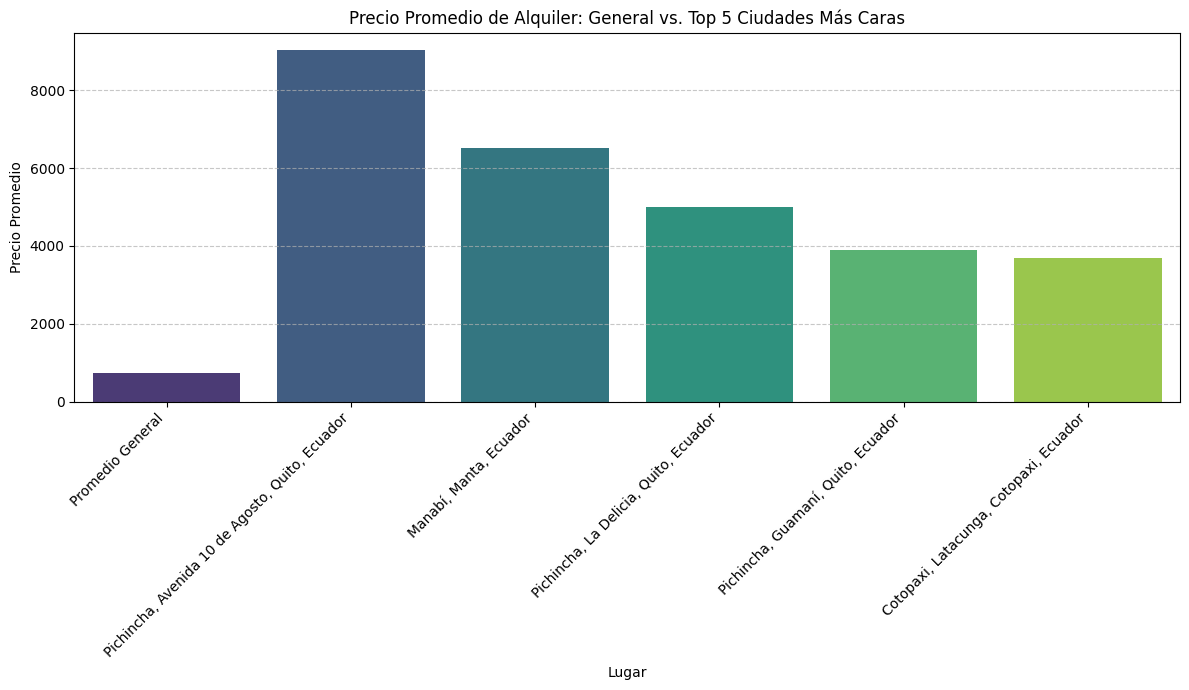

---------------------------------------------------------------------------------


In [38]:
# Para el gráfico de barras, vamos a comparar el precio promedio general con el precio promedio de las 5 ciudades más caras.

# Crear un DataFrame con el precio promedio general
precio_general_df = pd.DataFrame({'Lugar': ['Promedio General'], 'Precio': [precio_promedio]})

# Obtener los top 5 lugares más caros
top_5_ciudades_df = precio_promedio_por_lugar.head(5).reset_index()

# Combinar ambos DataFrames para la visualización
data_to_plot = pd.concat([precio_general_df, top_5_ciudades_df])

plt.figure(figsize=(12, 7))
sns.barplot(x='Lugar', y='Precio', data=data_to_plot, palette='viridis')
plt.title('Precio Promedio de Alquiler: General vs. Top 5 Ciudades Más Caras')
plt.xlabel('Lugar')
plt.ylabel('Precio Promedio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("---------------------------------------------------------------------------------")

### iii. Gráfico de dispersión de la relación entre Área y Precio

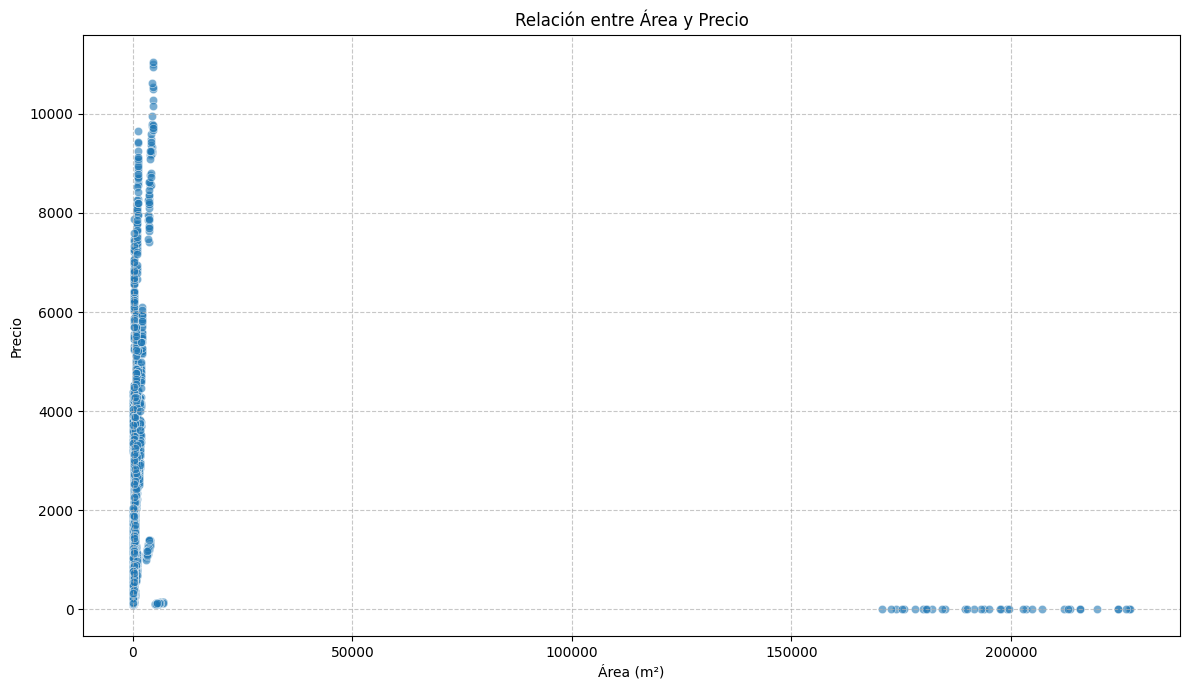

---------------------------------------------------------------------------------


In [39]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Area', y='Precio', data=RealStateEcuador.sample(frac=0.1, random_state=42), alpha=0.6)
plt.title('Relación entre Área y Precio')
plt.xlabel('Área (m²)')
plt.ylabel('Precio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("---------------------------------------------------------------------------------")

### iv. Gráfico de pastel de conteo de registros por Tipo de Propiedad

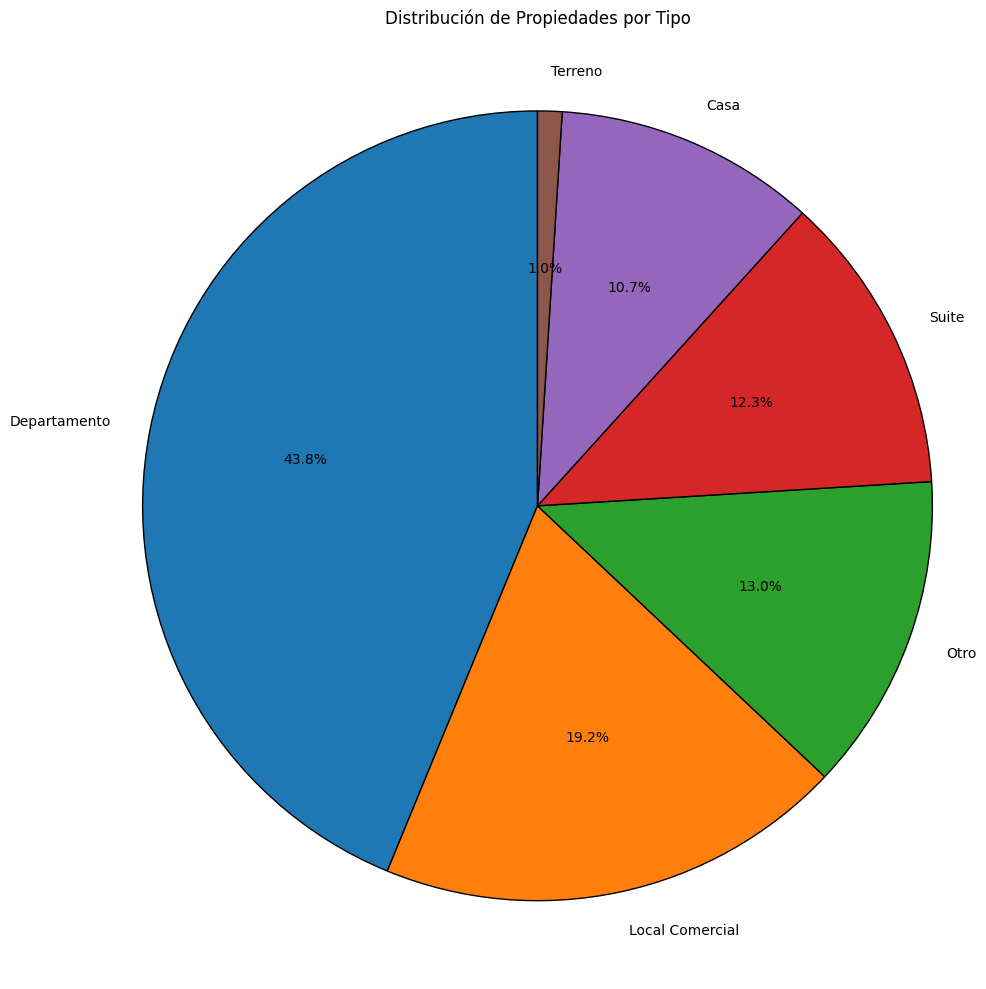

---------------------------------------------------------------------------------


In [40]:
plt.figure(figsize=(10, 10))
plt.pie(tipo_propiedad_conteo, labels=tipo_propiedad_conteo.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Distribución de Propiedades por Tipo')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

print("---------------------------------------------------------------------------------")

### v. Gráfico de Premium por Habitación Adicional

/tmp/ipykernel_647/199339517.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=premium_por_habitacion.index, y=premium_por_habitacion.values, palette='coolwarm')


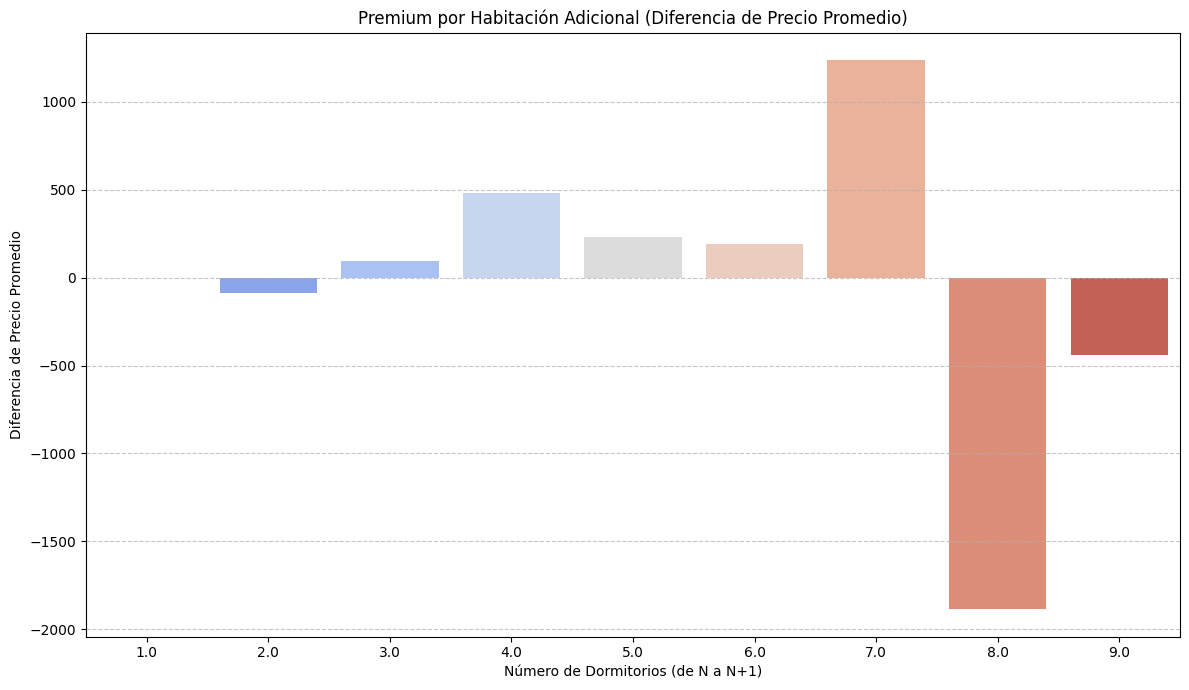

---------------------------------------------------------------------------------


In [41]:
plt.figure(figsize=(12, 7))
sns.barplot(x=premium_por_habitacion.index, y=premium_por_habitacion.values, palette='coolwarm')
plt.title('Premium por Habitación Adicional (Diferencia de Precio Promedio)')
plt.xlabel('Número de Dormitorios (de N a N+1)')
plt.ylabel('Diferencia de Precio Promedio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("---------------------------------------------------------------------------------")